In [ ]:
#Librerías que hemos instalado en otros notebooks:
! pip install langchain_openai
! pip install langchain_core
! pip install langchain-community

In [ ]:
import sys
!{sys.executable} -m pip install faiss-cpu
!{sys.executable} -m pip install chromadb

In [ ]:
API_KEY=""

# RAG (Retrieval-Augmented Generation)

Es una técnica que optimiza la salida de modelos de lenguaje grandes (LLM) al incorporar información externa relevante antes de generar una respuesta.<br>Combina dos componentes principales:

- Recuperación de información: Busca y extrae información relevante de una base de datos o corpus de documentos.
- Generación de respuestas: Utiliza un modelo de lenguaje para crear una respuesta precisa basada en la información recuperada.

**Ventajas**

- Implementación rentable al evitar reentrenamiento (fine-tunning) costoso
- Proporciona información actualizada y relevante
- Aumenta la confianza de los usuarios al citar fuentes
- Mayor control para los desarrolladores sobre las fuentes y el contenido

**Inconvenientes**

- Complejidad de implementación: Requiere varios pasos y componentes
- Depende de la calidad y disponibilidad de los datos externos
- Puede aumentar la latencia de respuesta
- Requiere mantenimiento de la base de conocimientos externa

### Procesos RAG

1. **Preparación de la base de conocimientos**
Se crea una colección de textos, documentos y datos relevantes como fuente de información externa.<br>
En este proceso, se preparan los documentos para su búsqueda eficiente:
- División de documentos en fragmentos más pequeños
- Creación de embeddings (representaciones vectoriales)
- Almacenamiento en una base de vectores

2. **Recuperación (Retrieve) de la información**
Cuando se recibe una consulta, el sistema busca y extrae información relevante de la base de conocimientos.

- Conversión de la consulta a embedding
- Búsqueda de similitud en el vector store
- Selección de los fragmentos más relevantes

3. **Ampliación de la indicación (Augment)**
La información recuperada se inserta en el contexto de la pregunta original, creando una consulta ampliada.

4. **Generación de respuestas (Generate)**
El LLM utiliza la consulta ampliada para generar una respuesta en lenguaje natural, combinando la información recuperada con su conocimiento previo.

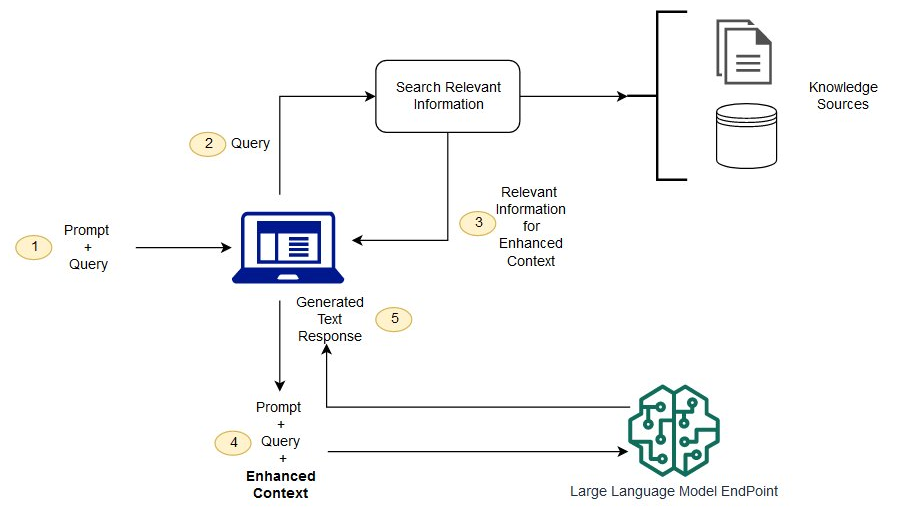

source: AWS https://aws.amazon.com/what-is/retrieval-augmented-generation/

### Búsqueda semántica vs. búsqueda léxica

En sistemas de recuperación de información existen dos enfoques principales para encontrar documentos relevantes: búsqueda léxica y búsqueda semántica. Entender la diferencia es fundamental para comprender el valor de RAG.

#### Búsqueda léxica (basada en keywords)

La búsqueda léxica se enfoca en encontrar coincidencias exactas de palabras o términos:

- **Funcionamiento**: Busca documentos que contengan las palabras exactas de la consulta.
- **Tecnologías**: Utiliza índices invertidos (como los usados en Elasticsearch, Solr, o bases de datos tradicionales).
- **Ejemplos**: Búsquedas booleanas (AND, OR, NOT), coincidencias exactas, expresiones regulares.

**Limitaciones**:
- No captura el significado o la intención detrás de las palabras
- Alta sensibilidad a errores ortográficos, sinónimos o paráfrasis
- Dificultad para manejar polisemia (palabras con múltiples significados)

#### Búsqueda semántica (basada en embeddings)

La búsqueda semántica busca capturar el significado y la intención detrás de las palabras:

- **Funcionamiento**: Transforma textos en vectores numéricos (embeddings) que capturan significado.
- **Tecnologías**: Utiliza bases de datos vectoriales (como Chroma, FAISS, Pinecone).
- **Métricas**: Similitud de coseno, distancia euclídea, producto punto.

**Ventajas**:
- Captura relaciones semánticas entre conceptos
- Maneja sinónimos, paráfrasis y variaciones lingüísticas
- Permite búsquedas por similitud conceptual, no solo léxica

#### Comparación práctica

| Consulta | Resultado búsqueda léxica | Resultado búsqueda semántica |
|----------|--------------------------|------------------------------|
| "efectos del calentamiento global" | Documentos con las palabras exactas "efectos", "calentamiento" y "global" | Documentos sobre consecuencias del cambio climático, incluso si no contienen esas palabras exactas |
| "cómo prevenir enfermedades cardíacas" | Documentos con esas palabras específicas | Documentos sobre salud cardiovascular, hábitos saludables, o prevención de infartos |


## Ejemplo RAG

In [ ]:
from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import CharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_classic.chains.combine_documents import create_stuff_documents_chain
from langchain_classic.chains import create_retrieval_chain


# 1. Cargar el documento
loader = TextLoader("responsible_IA.txt")
documents = loader.load()

# 2. Dividir el texto en chunks
text_splitter = CharacterTextSplitter(chunk_size=100, chunk_overlap=20)
texts = text_splitter.split_documents(documents)

# 3. Crear embeddings y almacenarlos en una base de datos vectorial
embeddings = OpenAIEmbeddings(api_key=API_KEY)
vectorstore = FAISS.from_documents(texts, embeddings)


In [ ]:
from langchain_core.prompts import ChatPromptTemplate

# 4. Crear un modelo de lenguaje
llm = ChatOpenAI(model_name="gpt-3.5-turbo", temperature=0, api_key=API_KEY)

# 5. Crear una plantilla de prompt
# create_stuff_documents_chain espera {context} (lista de documentos) y {input}
prompt = ChatPromptTemplate.from_template("""Usa la siguiente información para responder la pregunta del usuario. Si no sabes la respuesta, simplemente di que no lo sabes, no intentes inventar una respuesta.

Contexto: {context}

Pregunta: {input}

Respuesta:""")

In [ ]:
# 6. Crear la cadena de RAG
combine_docs_chain = create_stuff_documents_chain(llm, prompt)
qa_chain = create_retrieval_chain(
    vectorstore.as_retriever(search_kwargs={"k": 3}),
    combine_docs_chain,
)

# 7. Hacer una pregunta
question = "¿Cual es la aplicación actual de la IA en términos de inclusivilidad?"
result = qa_chain.invoke({"input": question})
print(result["answer"])
print("\nDocumentos de origen:")
for doc in result["context"]:
    print(doc.page_content)


### Retrievers en RAG

Los retrievers son componentes fundamentales en sistemas RAG, responsables de buscar y seleccionar la información más relevante para responder a una consulta. LangChain ofrece varios tipos de retrievers, cada uno con diferentes enfoques y casos de uso.

LangChain implementa cuatro estrategias principales para combinar retrievers con LLMs:

#### 1. Stuff (Empaquetado)

**Funcionamiento**: Toma todos los documentos recuperados y los coloca juntos en un solo prompt.

**Ventajas**:
- Simple y directo
- Funciona bien cuando los documentos recuperados son pocos y cortos
- El modelo ve todo el contexto de una vez

**Desventajas**:
- Limitado por la ventana de contexto del modelo
- No escala bien con muchos documentos
- No prioriza entre documentos de diferentes relevancia

**Caso de uso ideal**: Preguntas simples que requieren pocas fuentes para responder.

#### 2. Map-Reduce

**Funcionamiento**: Aplica el LLM a cada documento por separado (map) y luego combina los resultados (reduce).

**Ventajas**:
- Puede manejar grandes cantidades de documentos
- Procesamiento paralelo posible
- No limitado por la ventana de contexto

**Desventajas**:
- Más costoso (múltiples llamadas al LLM)
- Cada documento se procesa aisladamente (pierde contexto entre documentos)
- Respuestas a veces menos coherentes

**Caso de uso ideal**: Resúmenes de grandes colecciones de documentos o preguntas que requieren sintetizar mucha información.

#### 3. Refine (Refinamiento)

**Funcionamiento**: Construye una respuesta iterativamente, incorporando información de cada documento para refinar la respuesta anterior.

**Ventajas**:
- Bueno para respuestas largas y detalladas
- Puede incorporar información de muchos documentos
- Mantiene coherencia en la respuesta

**Desventajas**:
- Secuencial y lento (no paralelizable)
- Costoso en tokens (múltiples llamadas al LLM)
- Sesgado hacia información de documentos procesados primero

**Caso de uso ideal**: Generación de respuestas extensas y detalladas que incorporan múltiples fuentes.

#### 4. Map-Rerank

**Funcionamiento**: Aplica el LLM a cada documento, pide que evalúe la relevancia con un puntaje, y devuelve la respuesta con mejor puntuación.

**Ventajas**:
- Selecciona la mejor respuesta entre varias opciones
- Puede funcionar bien para preguntas factuales precisas
- Cada documento tiene igual oportunidad

**Desventajas**:
- No combina información entre documentos
- Múltiples llamadas al LLM (costoso)
- No ideal para preguntas que requieren información de múltiples fuentes

**Caso de uso ideal**: Preguntas específicas donde la respuesta completa probablemente esté en un solo documento.




### create_retrieval_chain

Esta es la forma moderna de construir una cadena de preguntas y respuestas en LangChain, reemplazando al antiguo `RetrievalQA`.

Sin memoria incorporada: Trata cada consulta de forma aislada, sin recordar consultas anteriores.
Enfoque en consultas únicas: Optimizado para responder preguntas individuales basadas en la información recuperada.
Más ligero: Al no mantener estado, es potencialmente más eficiente para consultas independientes.
Uso: Ideal para sistemas de preguntas y respuestas donde cada consulta es independiente y autocontenida.

**¿Cómo se construye?**

Se necesitan dos piezas que se ensamblan juntas:

```python
combine_docs_chain = create_stuff_documents_chain(llm, prompt)
qa_chain = create_retrieval_chain(retriever, combine_docs_chain)
```

**Parámetros de `create_retrieval_chain`:**
- `retriever`: El objeto que busca y recupera los documentos relevantes del vectorstore. Se obtiene con `vectorstore.as_retriever()`. Se puede configurar con `search_kwargs={"k": 3}` para controlar cuántos documentos recuperar.
- `combine_docs_chain`: La cadena que toma los documentos recuperados y los combina para generar la respuesta final. Se crea con `create_stuff_documents_chain(llm, prompt)`.

**Parámetros de `create_stuff_documents_chain`:**
- `llm`: El modelo de lenguaje que generará la respuesta. Puede ser cualquier modelo compatible con LangChain, como ChatOpenAI, VertexAI, etc.
- `prompt`: Un `ChatPromptTemplate` que define cómo se le presenta la información al modelo. Debe contener las variables `{context}` (donde se insertarán los documentos) y `{input}` (la pregunta del usuario).

**Tipos de combinación de documentos:**
- **stuff** (via `create_stuff_documents_chain`): Inserta todos los documentos recuperados juntos en un solo prompt y hace una única llamada al LLM. Simple y directo. Es el equivalente al antiguo `chain_type="stuff"`.
- **map_reduce**: Aplica el LLM a cada documento individualmente y luego combina los resultados. Ya no tiene wrapper directo — se modela con LCEL.
- **refine**: Construye una respuesta iterativamente, refinándola con cada documento. Ya no tiene wrapper directo — se modela con LCEL.
- **map_rerank**: Aplica el LLM a cada documento, puntúa las respuestas y devuelve la de mayor puntuación. Ya no tiene wrapper directo — se modela con LCEL.

**¿Cómo se invoca y qué devuelve?**

```python
result = qa_chain.invoke({"input": "tu pregunta aquí"})
```

- `result["answer"]` → la respuesta generada por el LLM.
- `result["input"]` → la pregunta original.
- `result["context"]` → lista de documentos recuperados del vectorstore (equivalente al antiguo `source_documents`).


In [ ]:
result

### ¿Qué es FAISS?
Es una base de datos vectorial. Las bases de datos vectoriales son fundamentales en sistemas RAG, ya que:

- Almacenamiento y recuperación eficiente: Estas bases de datos vectoriales permiten guardar y organizar grandes cantidades de embeddings de manera optimizada.
- Búsqueda rápida: Implementan algoritmos de búsqueda de similitud muy eficientes, lo que permite encontrar rápidamente los embeddings más cercanos a una consulta dada.
- Escalabilidad: Pueden manejar millones de vectores, algo crucial para aplicaciones del mundo real.
- Indexación: Crean índices especializados para acelerar las búsquedas semánticas.
- Persistencia: Permiten guardar los embeddings de forma duradera, evitando tener que recalcularlos cada vez.
- Metadatos: Facilitan asociar información adicional a cada embedding, útil para filtrado y recuperación.
- Optimización: Ofrecen opciones avanzadas para ajustar el rendimiento según las necesidades específicas.


| Característica | FAISS | Chroma |
|----------------|-------|--------|
| Desarrollador | Facebook AI Research | Trychroma.com |
| Enfoque principal | Alto rendimiento en grandes conjuntos | Facilidad de uso e integración |
| Instalación | `pip install faiss-cpu` o `faiss-gpu` | `pip install chromadb` |
| Persistencia | Manual (guardar/cargar índices) | Integrada (almacenamiento local o en la nube) |
| Metadatos | Limitado | Robusto |
| Escalabilidad | Excelente (millones de vectores) | Buena (optimizado para casos comunes) |
| Integración con LangChain | Vía `langchain_community.vectorstores` | Vía `langchain_community.vectorstores` |


In [ ]:
from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import CharacterTextSplitter
from langchain_community.vectorstores import Chroma
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.messages import HumanMessage, AIMessage
from langchain_classic.chains.combine_documents import create_stuff_documents_chain
from langchain_classic.chains import create_retrieval_chain, create_history_aware_retriever

#1. Preparación de la base de conocimientos
loader = TextLoader("responsible_IA.txt")
documents = loader.load()

text_splitter = CharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
texts = text_splitter.split_documents(documents)

embeddings = OpenAIEmbeddings(api_key=API_KEY)
vectorstore = Chroma.from_documents(texts, embeddings)

#2. Configurar modelo de chat
llm = ChatOpenAI(temperature=0, api_key=API_KEY)

# Prompt para reformular la pregunta teniendo en cuenta el historial de conversación
# Permite que el retriever entienda preguntas como "¿puedes explicar el primero?"
contextualize_prompt = ChatPromptTemplate.from_messages([
    ("system", "Dado el historial de conversación y la última pregunta del usuario, "
               "reformúlala como una pregunta autocontenida (sin necesidad del historial). "
               "Si ya es autocontenida, devuélvela tal cual."),
    MessagesPlaceholder("chat_history"),
    ("human", "{input}"),
])

# Retriever consciente del historial
history_aware_retriever = create_history_aware_retriever(llm, vectorstore.as_retriever(), contextualize_prompt)

# Prompt para generar la respuesta final
qa_prompt = ChatPromptTemplate.from_messages([
    ("system", "Usa el siguiente contexto para responder la pregunta. "
               "Si no sabes la respuesta, di que no lo sabes.\n\n{context}"),
    MessagesPlaceholder("chat_history"),
    ("human", "{input}"),
])

#3. Construir la cadena conversacional
combine_docs_chain = create_stuff_documents_chain(llm, qa_prompt)
qa = create_retrieval_chain(history_aware_retriever, combine_docs_chain)

#4. Chat con historial explícito (equivalente al ConversationBufferMemory anterior)
chat_history = []

query = "¿Cuáles son los principios de responsabilidad en la IA?"
result = qa.invoke({"input": query, "chat_history": chat_history})
print(result["answer"])

# Actualizar historial para la siguiente pregunta
chat_history.extend([HumanMessage(content=query), AIMessage(content=result["answer"])])

# Segunda pregunta — el historial permite referencias como "el primero", "eso", etc.
query2 = "¿Puedes explicar el primero con más detalle?"
result2 = qa.invoke({"input": query2, "chat_history": chat_history})
print("\n" + result2["answer"])


In [ ]:
result

### ConversationalRetrievalChain
Este componente está diseñado para mantener conversaciones con contexto y memoria:

Maneja historial de conversación: Mantiene un registro de preguntas y respuestas anteriores, permitiendo referencias a información previa.
Gestión de contexto: Puede incorporar el contexto de la conversación en curso para entender consultas que contienen referencias anafóricas (por ejemplo, "¿Y qué hay sobre esto?", "Cuéntame más sobre eso").
Estructura: Típicamente incluye un objeto memory que almacena el historial de conversación.
Uso: Ideal para chatbots o asistentes donde los usuarios mantienen diálogos extendidos y hacen preguntas relacionadas secuencialmente


### Ejercicio Ciudades 20 minutos

Crea un sistema RAG simple utilizando el texto proporcionado sobre las ciudades 20 minutos. El sistema debe ser capaz de responder preguntas básicas sobre el concepto, sus beneficios y desafíos.

In [ ]:
from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_classic.chains.combine_documents import create_stuff_documents_chain
from langchain_classic.chains import create_retrieval_chain


# 1. Cargar el documento

# 2. Dividir el texto en chunks

# 3. Crear embeddings y almacenarlos en una base de datos vectorial

# 4. Crear un modelo de lenguaje

# 5. Crear una plantilla de prompt


# 6. Crear la cadena de RAG

preguntas = [
    "¿Qué ciudades están implementando el concepto de ciudades 20 minutos?",
    "¿Qué son las ciudades 20 minutos?",
    "¿Cuáles son los beneficios de las ciudades 20 minutos?",
    "¿Cuál es el estado de las ciudades 20 minutos en España?",
]





In [ ]:
for pregunta in preguntas:
    respuesta = qa_chain.invoke({"input": pregunta})
    print(f"\nPregunta: {pregunta}")
    print(f"Respuesta: {respuesta['answer']}\n")
    if respuesta["context"]:
        print("Documentos de origen:")
        for doc in respuesta["context"]:
            print(doc.page_content)